# Iris Dataset Analysis

This notebook analyzes the classical iris dataset, focusing on label distribution visualization with both bar plots and pie charts using pastel colors.


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("pastel")


In [ ]:
# Load the iris dataset
iris = load_iris()

# Create a DataFrame for easier manipulation
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species_name'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display basic information about the dataset
print("Dataset shape:", iris_df.shape)
print("\nFirst few rows:")
print(iris_df.head())
print("\nDataset info:")
print(iris_df.info())
print("\nSpecies distribution:")
print(iris_df['species_name'].value_counts())


Dataset shape: (150, 6)

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length

# Label Distribution Analysis

Now let's visualize the distribution of species labels using both bar plot and pie chart with pastel colors.


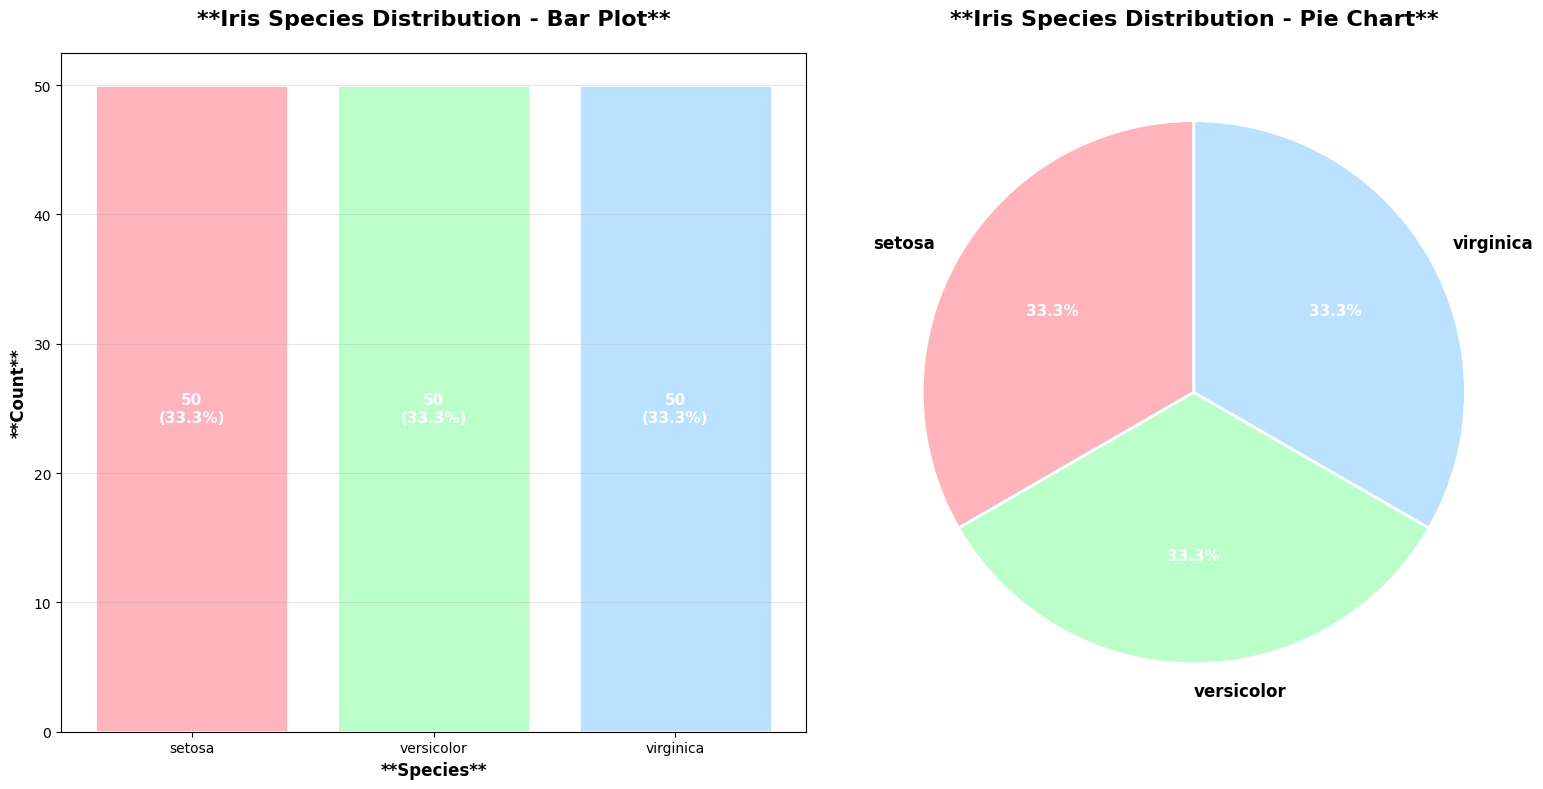

Species Distribution Summary:
Setosa: 50 samples (33.3%)
Versicolor: 50 samples (33.3%)
Virginica: 50 samples (33.3%)


In [ ]:
# Define pastel colors for consistent visualization
pastel_colors = ['#FFB3BA', '#BAFFC9', '#BAE1FF']  # Light pink, light green, light blue

# Get species counts
species_counts = iris_df['species_name'].value_counts()

# Create figure with subplots for both bar plot and pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Bar Plot
bars = ax1.bar(species_counts.index, species_counts.values, 
               color=pastel_colors, edgecolor='white', linewidth=2)
ax1.set_title('**Iris Species Distribution - Bar Plot**', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('**Species**', fontsize=12, fontweight='bold')
ax1.set_ylabel('**Count**', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars with white text
for bar, count in zip(bars, species_counts.values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height/2,
             f'{count}\n({count/len(iris_df)*100:.1f}%)',
             ha='center', va='center', fontweight='bold', color='white', fontsize=11)

# Pie Chart
wedges, texts, autotexts = ax2.pie(species_counts.values, labels=species_counts.index, 
                                   colors=pastel_colors, autopct='%1.1f%%',
                                   startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('**Iris Species Distribution - Pie Chart**', fontsize=16, fontweight='bold', pad=20)

# Style the pie chart text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(12)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Species Distribution Summary:")
print("="*40)
for species, count in species_counts.items():
    percentage = (count / len(iris_df)) * 100
    print(f"{species.capitalize()}: {count} samples ({percentage:.1f}%)")


## Additional Analysis

Let's also look at some basic statistics of the features for each species to get a better understanding of the dataset.


In [ ]:
# Display descriptive statistics for each species
print("Descriptive Statistics by Species:")
print("="*50)

def calculate_stats(data, precision=2):
    return data.describe().round(precision)

for species in iris_df['species_name'].unique():
    print(f"\n{species.upper()}:")
    species_data = iris_df[iris_df['species_name'] == species].iloc[:, :-2]  # Exclude species columns
    print(calculate_stats(species_data, 2))

# Display correlation matrix
print("\n" + "="*50)
print("Feature Correlation Matrix:")
print("="*50)

# Calculate correlation matrix for all numeric features
correlation_matrix = iris_df.iloc[:, :-2].corr()  # Exclude species columns
print(correlation_matrix.round(3))


Descriptive Statistics by Species:

SETOSA:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count              50.00             50.00              50.00   
mean                5.01              3.43               1.46   
std                 0.35              0.38               0.17   
min                 4.30              2.30               1.00   
25%                 4.80              3.20               1.40   
50%                 5.00              3.40               1.50   
75%                 5.20              3.68               1.58   
max                 5.80              4.40               1.90   

       petal width (cm)  
count             50.00  
mean               0.25  
std                0.11  
min                0.10  
25%                0.20  
50%                0.20  
75%                0.30  
max                0.60  

VERSICOLOR:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count              50.00             50.00              50